## 1. Import Libraries

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 2. Load Dataset

In [7]:

df = pd.read_excel("marketing_campaign.xlsx", engine="openpyxl")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## 3. Dataset Overview

Check:
- Number of rows and columns
- Column names
- Data types
- Basic structure


In [8]:
df.shape

(2240, 29)

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

## 4. Data Quality Check

We will check:
- Missing values
- Duplicate records
- Unique values
- Basic statistics


In [11]:
df.isnull().sum().sort_values(ascending=False)

Income                 24
ID                      0
NumDealsPurchases       0
Z_Revenue               0
Z_CostContact           0
Complain                0
AcceptedCmp2            0
AcceptedCmp1            0
AcceptedCmp5            0
AcceptedCmp4            0
AcceptedCmp3            0
NumWebVisitsMonth       0
NumStorePurchases       0
NumCatalogPurchases     0
NumWebPurchases         0
MntGoldProds            0
Year_Birth              0
MntSweetProducts        0
MntFishProducts         0
MntMeatProducts         0
MntFruits               0
MntWines                0
Recency                 0
Dt_Customer             0
Teenhome                0
Kidhome                 0
Marital_Status          0
Education               0
Response                0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


## 5. Investigate Potential Data-Quality Issues

Do not automatically delete unusual observations. First identify and investigate them.


In [14]:
df["Year_Birth"].describe()

count    2240.000000
mean     1968.805804
std        11.984069
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64

In [15]:
df[df["Year_Birth"] < 1900]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,4,0,0,0,0,0,0,3,11,0
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,1,0,0,1,0,0,0,3,11,0


In [16]:
df[df["Income"] > 200000]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,6,0,0,0,0,0,0,3,11,0


In [17]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

## 6. Categorical Variables — Customer Profile

In [18]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

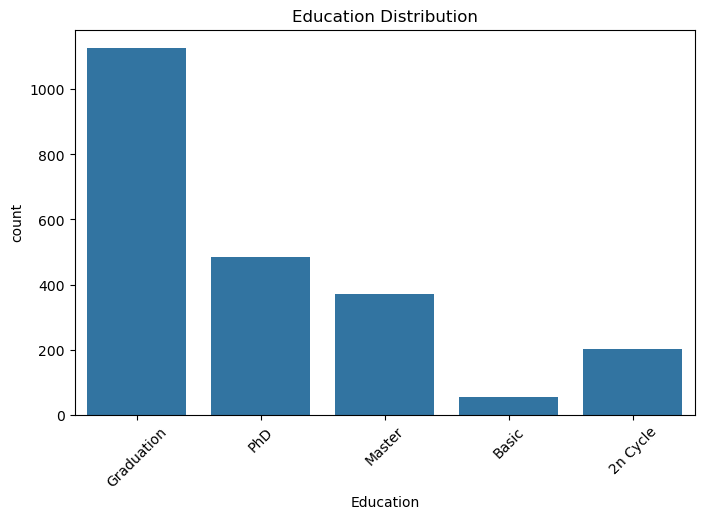

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Education")

plt.title("Education Distribution")
plt.xticks(rotation=45)
plt.show()

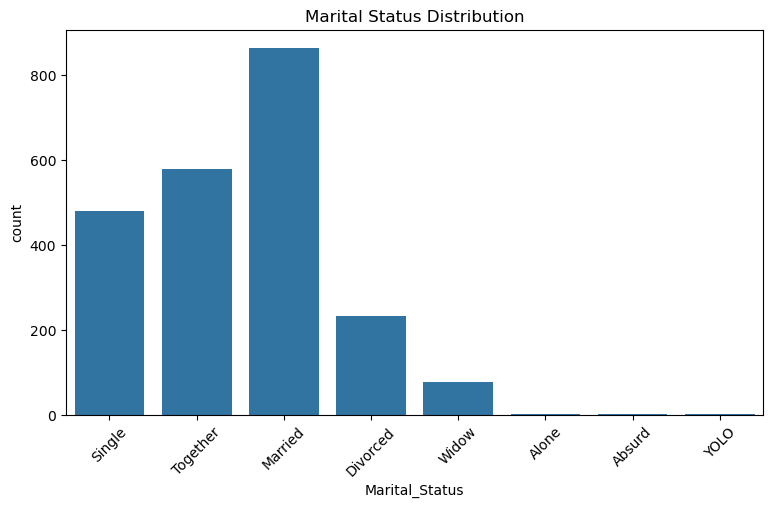

In [21]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, x="Marital_Status")

plt.title("Marital Status Distribution")
plt.xticks(rotation=45)
plt.show()

## 7. Numerical EDA — Income and Recency

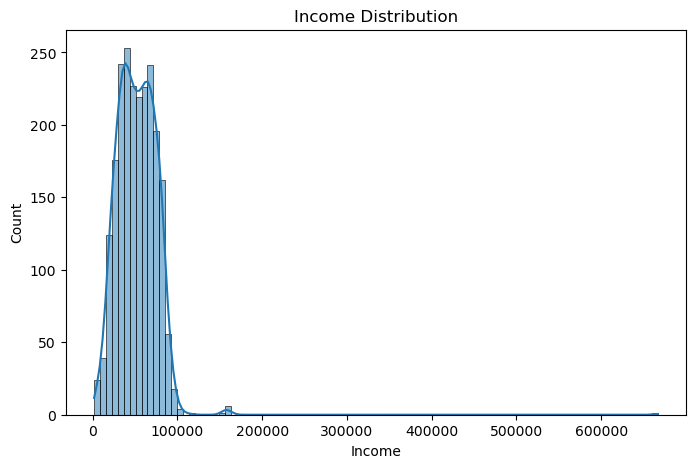

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Income", kde=True)

plt.title("Income Distribution")
plt.show()

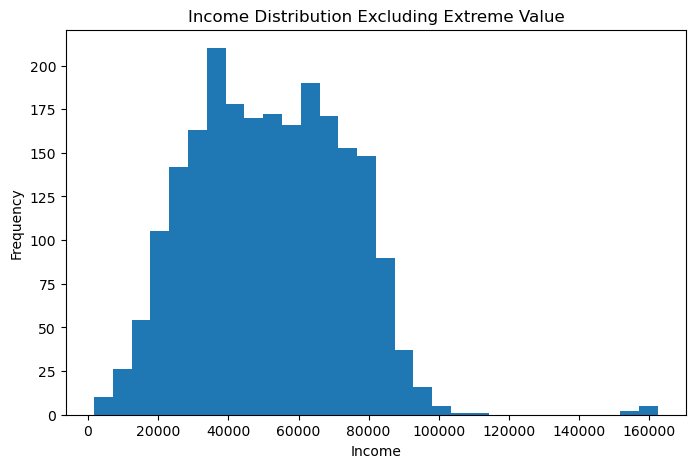

In [23]:
df[df["Income"] < 200000]["Income"].plot(
    kind="hist",
    bins=30,
    figsize=(8,5)
)

plt.title("Income Distribution Excluding Extreme Value")
plt.xlabel("Income")
plt.show()

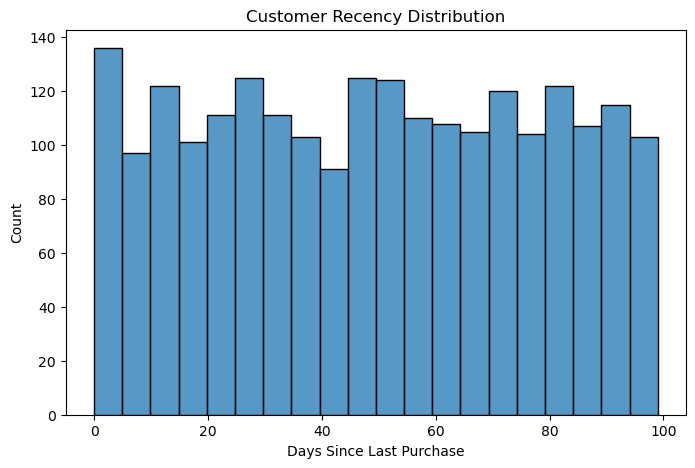

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Recency", bins=20)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.show()

In [25]:
df["Recency"].describe()

count    2240.000000
mean       49.109375
std        28.962453
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64

## 8. Product Spending Analysis

The dataset contains spending on wine, fruits, meat, fish, sweets and gold.


In [26]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

In [27]:
df[spending_cols].mean().sort_values()

MntFruits            26.302232
MntSweetProducts     27.062946
MntFishProducts      37.525446
MntGoldProds         44.021875
MntMeatProducts     166.950000
MntWines            303.935714
dtype: float64

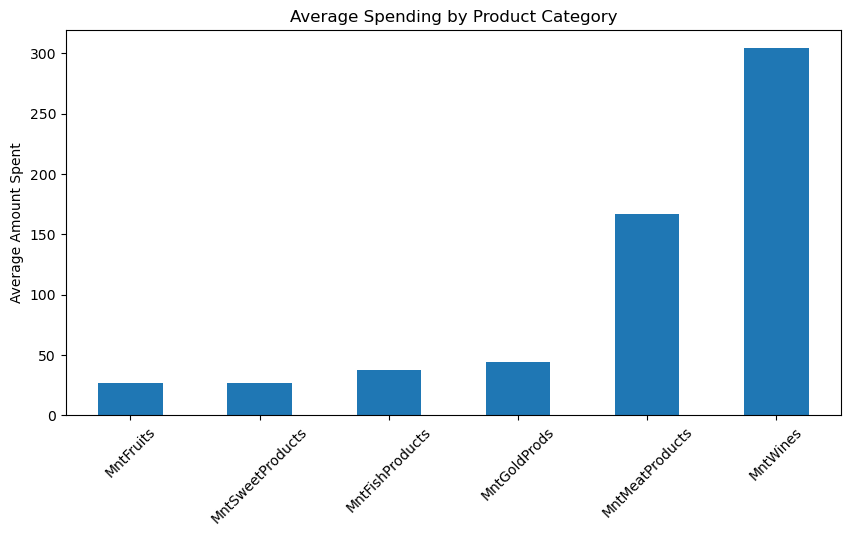

In [28]:
plt.figure(figsize=(10,5))

df[spending_cols].mean().sort_values().plot(kind="bar")

plt.title("Average Spending by Product Category")
plt.ylabel("Average Amount Spent")
plt.xticks(rotation=45)
plt.show()

## 9. Feature Engineering for EDA

Create useful summary variables for exploration. These are **not yet the final clustering features**.


In [29]:
df["Total_Spending"] = df[spending_cols].sum(axis=1)

In [30]:
df["Total_Spending"].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: Total_Spending, dtype: float64

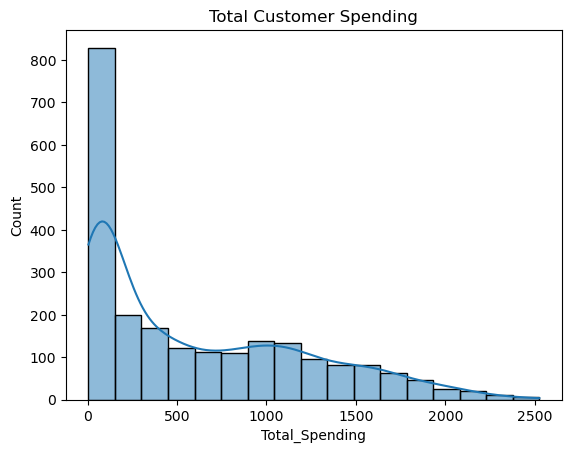

In [31]:
sns.histplot(data=df, x="Total_Spending", kde=True)

plt.title("Total Customer Spending")
plt.show()

## 10. Purchase-Channel Analysis

In [32]:
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

In [33]:
df[purchase_cols].mean()

NumWebPurchases        4.084821
NumCatalogPurchases    2.662054
NumStorePurchases      5.790179
dtype: float64

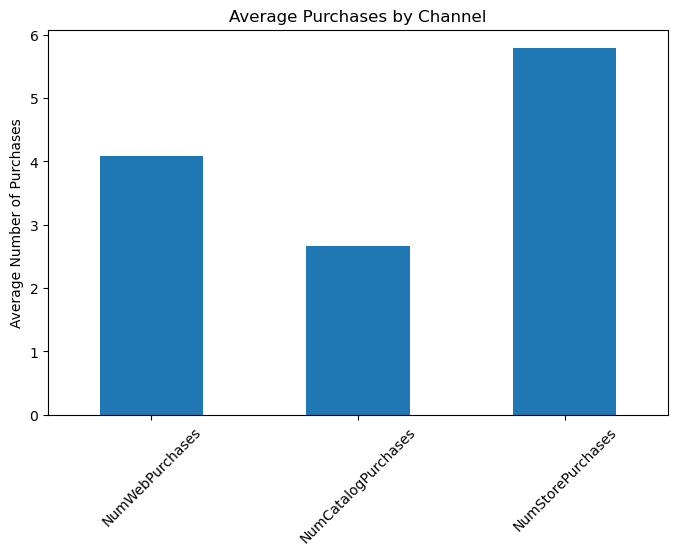

In [34]:
plt.figure(figsize=(8,5))

df[purchase_cols].mean().plot(kind="bar")

plt.title("Average Purchases by Channel")
plt.ylabel("Average Number of Purchases")
plt.xticks(rotation=45)
plt.show()

Total Purchases per Customer

In [35]:
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

In [36]:
df["Total_Purchases"].describe()

count    2240.000000
mean       12.537054
std         7.205741
min         0.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        32.000000
Name: Total_Purchases, dtype: float64

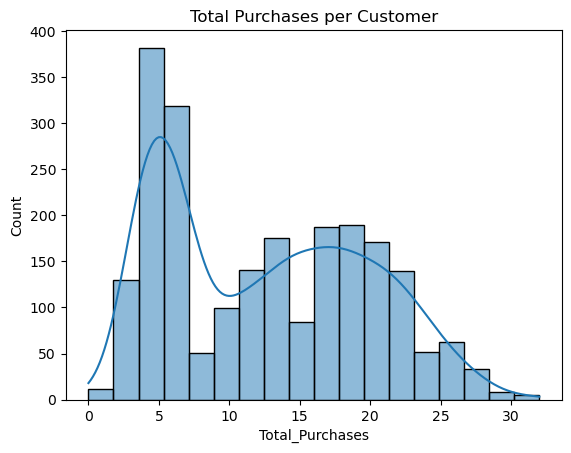

In [37]:
sns.histplot(data=df, x="Total_Purchases", kde=True)

plt.title("Total Purchases per Customer")
plt.show()

## 11. Promotion / Campaign Analysis

Purchases Made with Discounts

In [38]:
df["NumDealsPurchases"].describe()

count    2240.000000
mean        2.325000
std         1.932238
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: NumDealsPurchases, dtype: float64

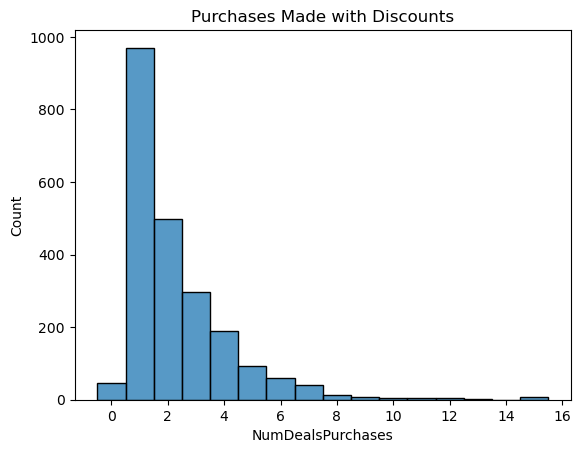

In [39]:
sns.histplot(data=df, x="NumDealsPurchases", discrete=True)

plt.title("Purchases Made with Discounts")
plt.show()

Response to Last Campaign

In [40]:
df["Response"].value_counts()

Response
0    1906
1     334
Name: count, dtype: int64

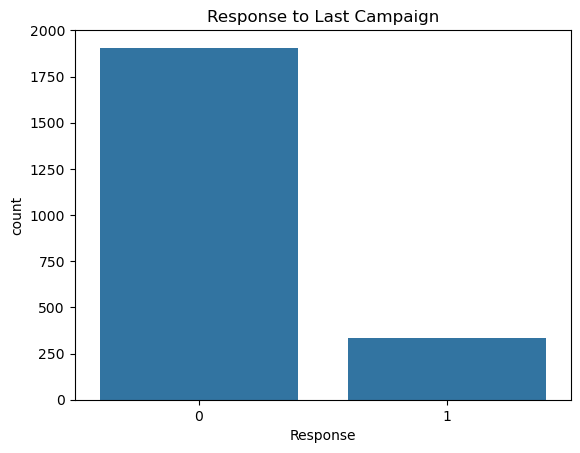

In [41]:
sns.countplot(data=df, x="Response")

plt.title("Response to Last Campaign")
plt.show()

## 12. Important Bivariate Relationships

Number of Children/Teenagers in Household

In [42]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [43]:
df["Total_Children"].value_counts().sort_index()

Total_Children
0     638
1    1128
2     421
3      53
Name: count, dtype: int64

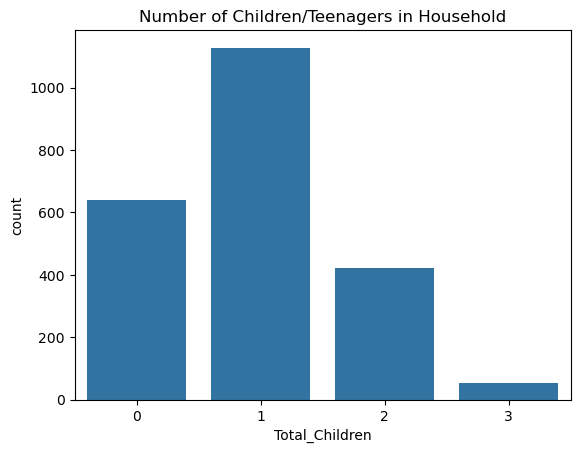

In [44]:
sns.countplot(data=df, x="Total_Children")

plt.title("Number of Children/Teenagers in Household")
plt.show()

In [45]:
numeric_cols = df.select_dtypes(include=np.number).columns

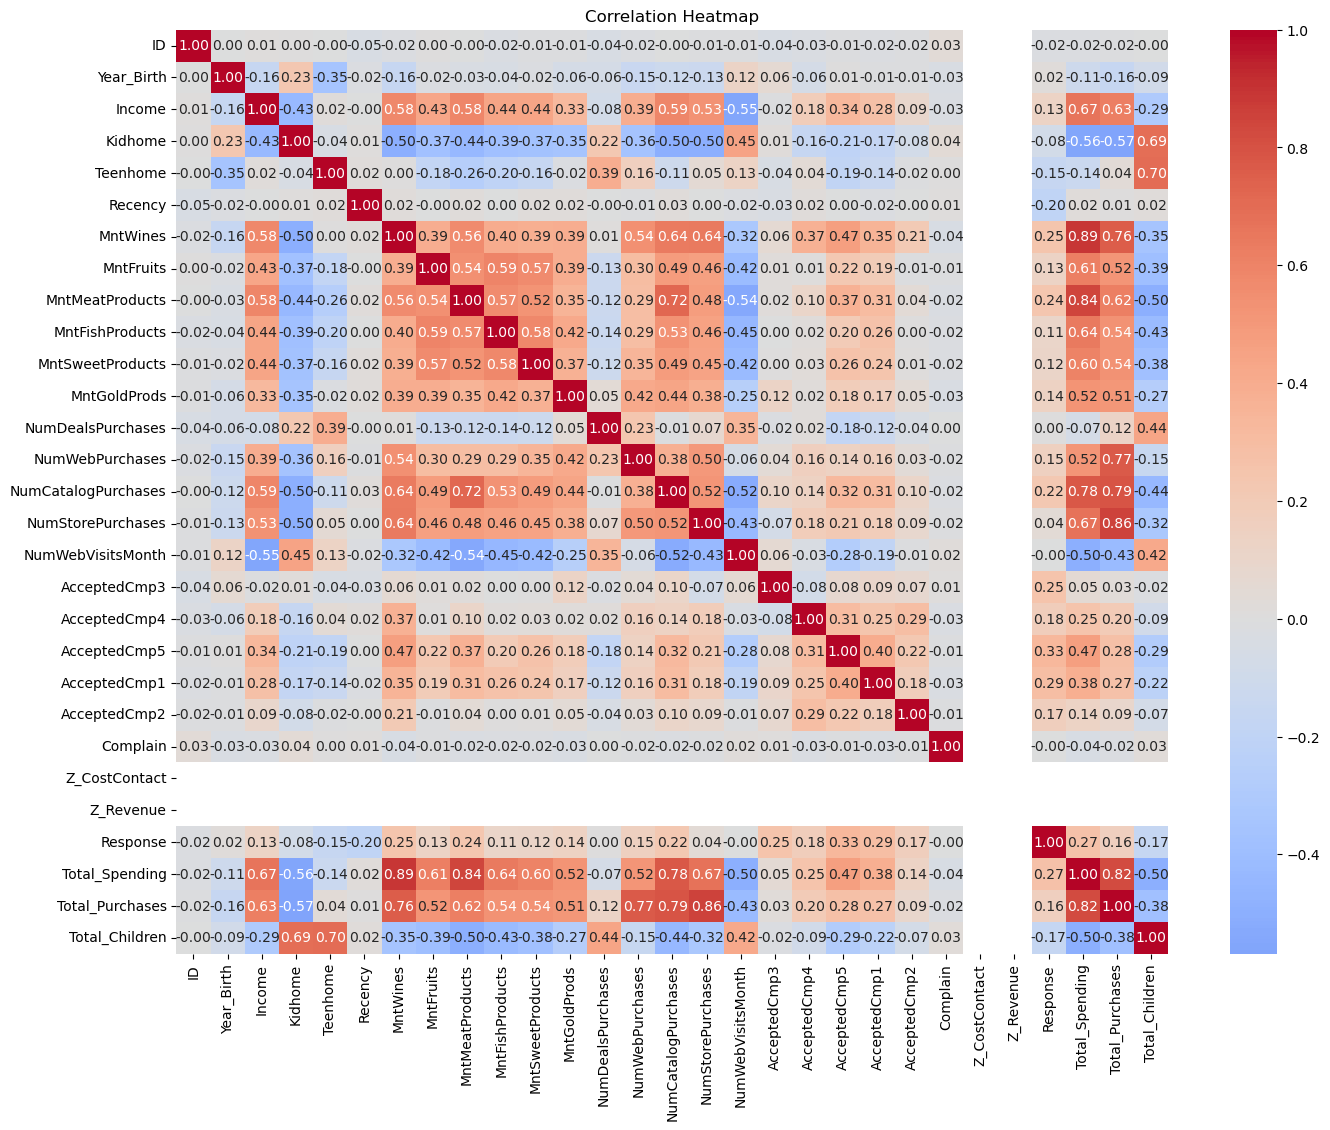

In [51]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df[numeric_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,      
    fmt=".2f"         
)

plt.title("Correlation Heatmap")
plt.show()

## 13. Correlation Analysis


Income vs Total Spending

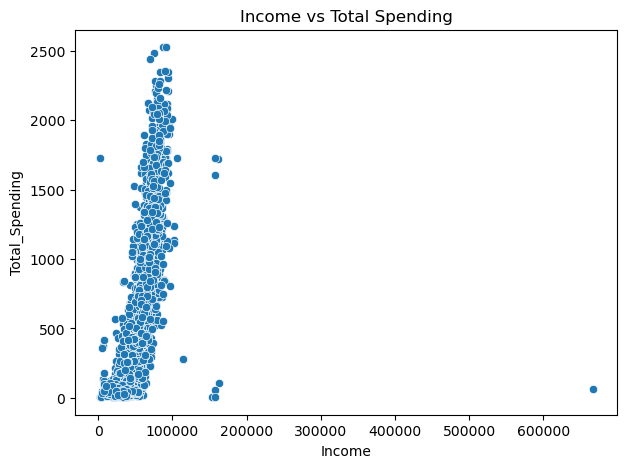

In [47]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending"
)

plt.title("Income vs Total Spending")
plt.show()

Recency vs Total Spending

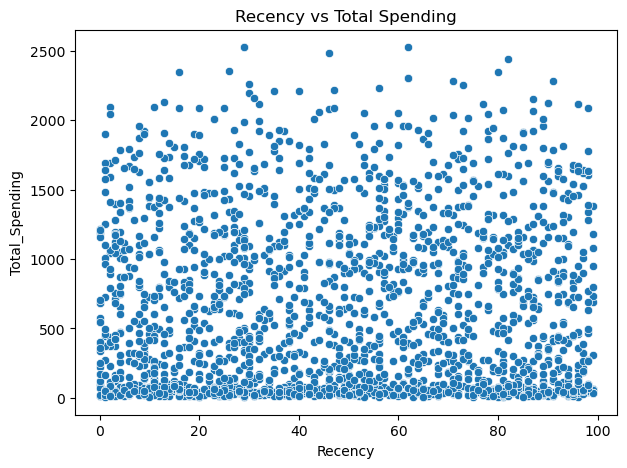

In [48]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Recency",
    y="Total_Spending"
)

plt.title("Recency vs Total Spending")
plt.show()

Website Visits vs Web Purchases

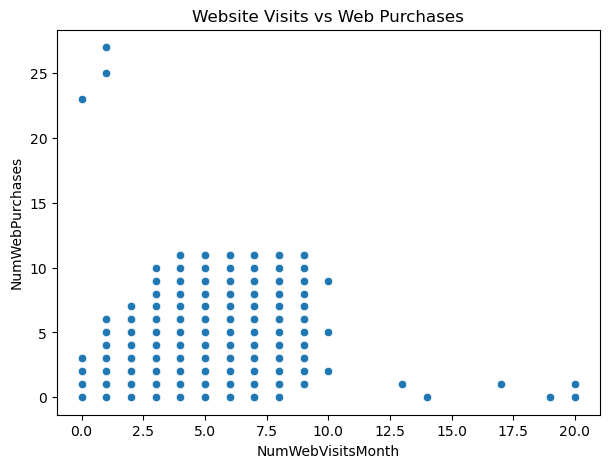

In [49]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="NumWebVisitsMonth",
    y="NumWebPurchases"
)

plt.title("Website Visits vs Web Purchases")
plt.show()

## 13. EDA Findings & Conclusion

### 13.1 Data Quality Findings
- The dataset contains 2,240 customer records and 29 variables.
- Missing values were identified in the `Income` variable and need to be handled before model building.
- No duplicate records were identified.
- Potentially unusual values were observed in `Year_Birth` and `Income` and require further investigation before clustering.
- `Z_CostContact` and `Z_Revenue` contain constant values and therefore do not provide useful variation for customer segmentation.

### 13.2 Customer Profile
- `Education` and `Marital_Status` show the demographic composition of the customers.
- `Income` shows variation across customers, with potential extreme values that should be investigated.
- `Recency` shows differences in how recently customers made their last purchase.

### 13.3 Spending Behavior
- Customers show different spending patterns across wine, fruits, meat, fish, sweets and gold products.
- `Total_Spending` was created to represent the overall spending behavior of each customer.
- The distribution of total spending should be considered when deciding how to preprocess the data for clustering.

### 13.4 Purchase Behavior
- Customers use different purchasing channels, including web, catalogue and store purchases.
- `Total_Purchases` was created to summarize the overall purchase frequency.
- Website visits and web purchases were explored to understand online purchasing behavior.

### 13.5 Promotion Behavior
- `NumDealsPurchases` was analyzed to understand customers' use of discounts.
- Campaign response was analyzed using the `Response` variable.
- Campaign-related variables may provide useful information for customer profiling, but their use as clustering features should be discussed before model building.

### 13.6 Overall Conclusion
The EDA shows that customers differ in their demographic characteristics, spending patterns, purchase frequency, purchase channels, recency and response to promotions. These differences provide a basis for customer segmentation.

Before clustering, the identified data-quality issues should be handled and the appropriate features should be selected. Numerical variables will then require appropriate preprocessing and scaling before applying clustering algorithms.

## 14. Candidate Features for Clustering

Based on the EDA, the following variables are potential candidates for customer segmentation:

### Customer / Behavioral Features

- `Income` — customer's yearly household income
- `Recency` — number of days since the last purchase
- `Total_Spending` — total spending across all product categories
- `Total_Purchases` — total purchases across web, catalogue and store channels
- `NumDealsPurchases` — number of purchases made using discounts
- `NumWebPurchases` — number of purchases made through the website
- `NumCatalogPurchases` — number of purchases made through the catalogue
- `NumStorePurchases` — number of purchases made directly in stores
- `NumWebVisitsMonth` — number of website visits during the last month
- `Total_Children` — combined number of children and teenagers in the household

### Product Spending Features

The individual product-spending variables may also be considered:

- `MntWines`
- `MntFruits`
- `MntMeatProducts`
- `MntFishProducts`
- `MntSweetProducts`
- `MntGoldProds`

### Variables Requiring Further Discussion

The following variables should be discussed before finalizing the clustering feature set:

- `Education`
- `Marital_Status`
- `AcceptedCmp1`
- `AcceptedCmp2`
- `AcceptedCmp3`
- `AcceptedCmp4`
- `AcceptedCmp5`
- `Response`
- `Complain`

Categorical variables will require appropriate encoding if they are included.

Campaign-response variables may be used either as clustering features or for profiling/evaluating the resulting customer segments.

### Variables Not Intended for Clustering

- `ID` — customer identifier; it does not represent customer behavior.
- `Z_CostContact` — constant variable.
- `Z_Revenue` — constant variable.


## 15. Customer Age Analysis
To analyze the age distribution of customers to understand the demographic profile.

In [50]:
import datetime

current_year = datetime.datetime.now().year
df["Age"] = current_year - df["Year_Birth"]

df["Age"].describe()

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

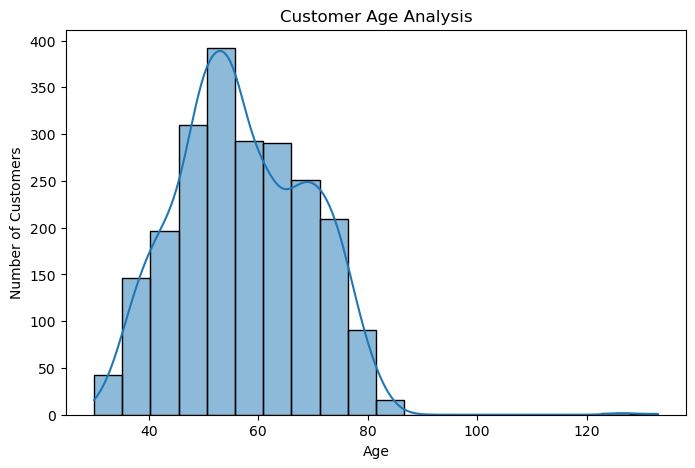

In [78]:
#Histplot Visualization
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Customer Age Analysis")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [56]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])
df["Dt_Customer"].min(), df["Dt_Customer"].max()

(Timestamp('2012-07-30 00:00:00'), Timestamp('2014-06-29 00:00:00'))

## 16. Customer Tenure Analysis
Checking customer enrollment dates to understand the length of customer relationships.

In [58]:
reference_date = df["Dt_Customer"].max()

df["Tenure_Days"] = (
    reference_date - df["Dt_Customer"]
).dt.days

df["Tenure_Days"].describe()

count    2240.000000
mean      353.582143
std       202.122512
min         0.000000
25%       180.750000
50%       355.500000
75%       529.000000
max       699.000000
Name: Tenure_Days, dtype: float64

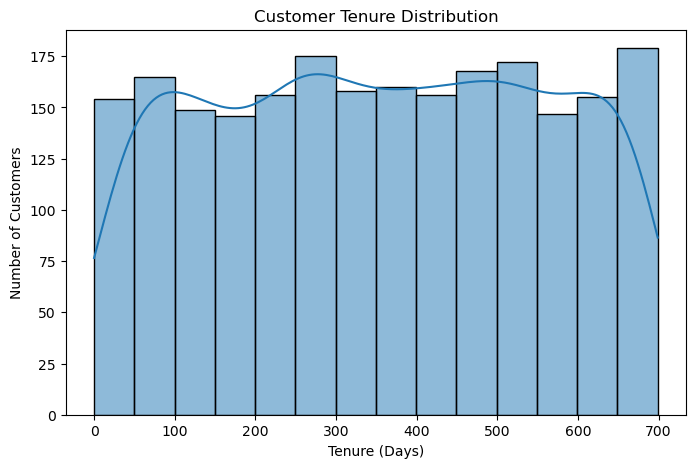

In [80]:
#Histplot Visualization
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Tenure_Days", kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Days)")
plt.ylabel("Number of Customers")
plt.show()

## 17. Age vs Total Spending
Analyzing the relationship between customer age and total spending.

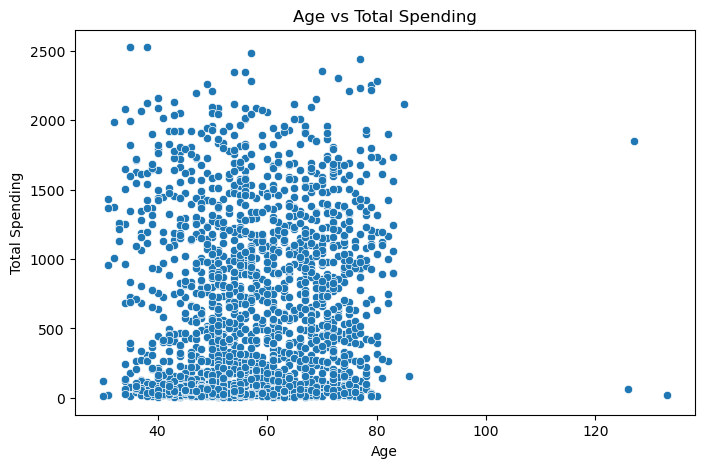

In [60]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total_Spending"
)

plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.show()

## 18. Education vs Total Spending
Comparing average customer spending across different education levels.

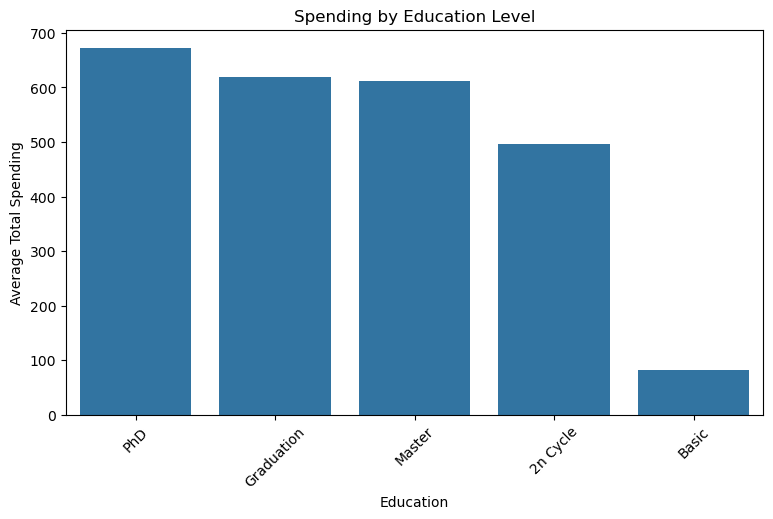

In [77]:
education_spending = (
    df.groupby("Education")["Total_Spending"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=education_spending.index,
    y=education_spending.values
)

plt.title("Spending by Education Level")
plt.xlabel("Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [62]:
df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

Education
PhD           672.409465
Graduation    619.898846
Master        611.781081
2n Cycle      496.527094
Basic          81.796296
Name: Total_Spending, dtype: float64

## 19. Marital Status vs Total Spending
Comparing average customer spending across different marital-status groups.

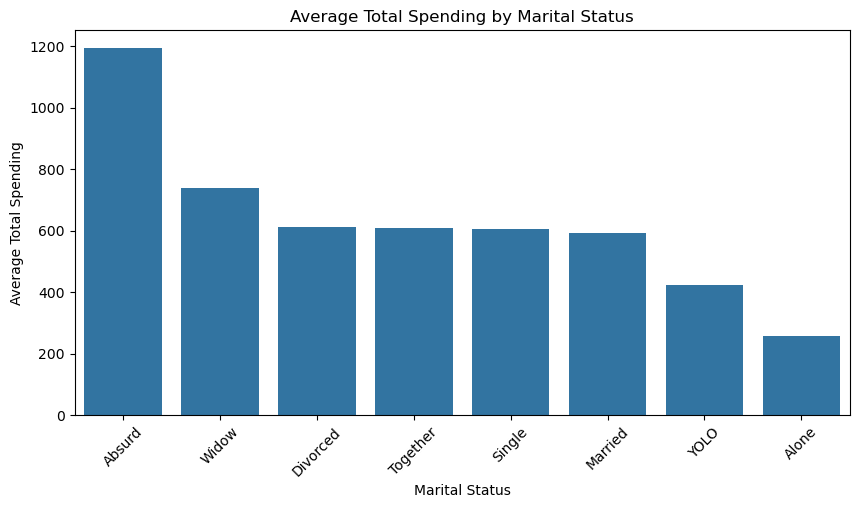

In [79]:
marital_spending = (
    df.groupby("Marital_Status")["Total_Spending"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=marital_spending.index,
    y=marital_spending.values
)

plt.title("Average Total Spending by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [64]:
df.groupby("Marital_Status")["Total_Spending"].mean().sort_values(ascending=False)

Marital_Status
Absurd      1192.500000
Widow        738.818182
Divorced     610.629310
Together     608.387931
Single       606.483333
Married      590.802083
YOLO         424.000000
Alone        256.666667
Name: Total_Spending, dtype: float64

## 20. Purchase Channel Preference
Analyzing customer purchasing behavior across web, catalogue, and store channels.

In [67]:
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["Total_Channel_Purchases"] = df[purchase_cols].sum(axis=1)

df["Web_Purchase_Pct"] = (
    df["NumWebPurchases"] / df["Total_Channel_Purchases"] * 100
)

df["Catalog_Purchase_Pct"] = (
    df["NumCatalogPurchases"] / df["Total_Channel_Purchases"] * 100
)

df["Store_Purchase_Pct"] = (
    df["NumStorePurchases"] / df["Total_Channel_Purchases"] * 100
)

In [68]:
df[
    [
        "Web_Purchase_Pct",
        "Catalog_Purchase_Pct",
        "Store_Purchase_Pct"
    ]
].mean()

Web_Purchase_Pct        32.987425
Catalog_Purchase_Pct    16.480892
Store_Purchase_Pct      50.531683
dtype: float64

## 21. Campaign Acceptance Rate Analysis
Analyzing customer acceptance rates across different marketing campaigns.

In [71]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

campaign_rates = df[campaign_cols].mean() * 100

campaign_rates

AcceptedCmp1     6.428571
AcceptedCmp2     1.339286
AcceptedCmp3     7.276786
AcceptedCmp4     7.455357
AcceptedCmp5     7.276786
Response        14.910714
dtype: float64

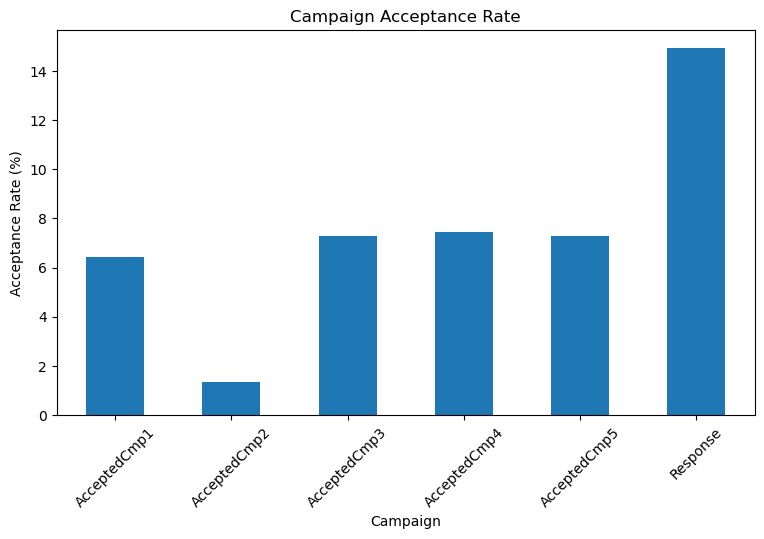

In [72]:
plt.figure(figsize=(9,5))

campaign_rates.plot(kind="bar")

plt.title("Campaign Acceptance Rate")
plt.ylabel("Acceptance Rate (%)")
plt.xlabel("Campaign")
plt.xticks(rotation=45)
plt.show()

## 22. Customer Behavioral Profiling
Analyzing demographic, spending, purchasing, and campaign variables to understand overall customer behavior.

In [73]:
behavior_cols = [
    "Income",
    "Age",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Total_Children"
]

df[behavior_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.0,666666.0
Age,2240.0,57.194196,11.984069,30.0,49.00,56.0,67.0,133.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.0,99.0
Total_Spending,2240.0,605.798214,602.249288,5.0,68.75,396.0,1045.5,2525.0
Total_Purchases,2240.0,12.537054,7.205741,0.0,6.00,12.0,18.0,32.0
NumDealsPurchases,2240.0,2.325000,1.932238,0.0,1.00,2.0,3.0,15.0
NumWebVisitsMonth,2240.0,5.316518,2.426645,0.0,3.00,6.0,7.0,20.0
Total_Children,2240.0,0.950446,0.751803,0.0,0.00,1.0,1.0,3.0


### Additional EDA Contribution 
#### - Shiva Ram Naradashi
As part of my individual contribution to the EDA phase, I performed the following analyses:

| Section | Analysis | Contribution |
|---|---|---|
| 15 | Customer Age Analysis | Analyzed customer age distribution |
| 16 | Customer Tenure Analysis | Analyzed customer enrollment and tenure |
| 17 | Age vs Total Spending | Studied age and spending relationship |
| 18 | Education vs Total Spending | Compared spending across education levels |
| 19 | Marital Status vs Total Spending | Compared spending across marital-status groups |
| 20 | Purchase Channel Preference | Analyzed web, catalogue, and store purchases |
| 21 | Campaign Acceptance Rate Analysis | Compared campaign acceptance rates |
| 22 | Customer Behavioral Profiling | Summarized customer behavioral characteristics |

## 23. EDA Findings 
##### - Shiva Ram Naradashi
### 23.1 Customer Profile Findings

- The dataset contains 2,240 customer records with demographic, spending, purchasing, and campaign-related information.
- Customer age shows variation across the customer base, which helps in understanding different customer groups.
- Education and marital status show differences in customer spending behavior.
- Customer tenure provides information about the length of the customer relationship with the company.

### 23.2 Spending Behavior Findings

- Customers have different spending patterns across wine, fruits, meat, fish, sweets, and gold products.
- `Total_Spending` provides a useful summary of overall customer spending behavior.
- The analysis of age and total spending helps understand differences in spending behavior across customers.
- Education and marital status were also analyzed in relation to total spending to identify differences in customer spending patterns.

### 23.3 Purchase Behavior Findings

- Customers use different purchasing channels, including web, catalogue, and stores.
- Purchase-channel preferences vary across customers.
- `NumWebPurchases`, `NumCatalogPurchases`, and `NumStorePurchases` provide useful information about customer purchasing behavior.
- Purchase channel preference was further analyzed to understand the different ways customers interact with the company.

### 23.4 Campaign Findings

- Customers show different response rates across the marketing campaigns.
- Campaign acceptance variables provide information about customer engagement with promotional offers.
- `Response` helps identify differences in customer engagement with the most recent campaign.
- Campaign acceptance rates were compared across the different campaigns to understand customer response to promotional activities.

### 23.5 Customer Tenure Findings

- `Dt_Customer` was analyzed to understand when customers joined the company.
- Customer tenure provides additional information about the length of the customer relationship.
- Tenure can be considered as an additional customer characteristic during customer profiling.

### 23.6 Clustering Preparation

Based on the EDA, several variables provide useful information for customer segmentation, including:

- `Income`
- `Recency`
- `Total_Spending`
- `Total_Purchases`
- `NumDealsPurchases`
- `NumWebPurchases`
- `NumCatalogPurchases`
- `NumStorePurchases`
- `NumWebVisitsMonth`
- `Total_Children`

These variables can be further evaluated and preprocessed before applying clustering techniques such as K-Means and other clustering algorithms.

### 23.7 Overall Conclusion

The EDA identified differences in customer demographics, spending behavior, purchasing channels, customer tenure, and campaign engagement. The additional analyses provided further insights into customer behavior and can support the next stage of customer segmentation.

Before clustering, the selected features should be cleaned, appropriately transformed and scaled, and evaluated for redundancy and correlation.